# APPROCHE 3 : MACHINE LEARNING (RANDOM FOREST)

## Introduction

Le Machine Learning offre une approche data-driven pour modeliser l'ER en capturant les interactions complexes entre variables sans hypotheses parametriques rigides.

## Objectif

Predire le taux de remboursement anticipe (ER) en utilisant les caracteristiques individuelles des contrats et des emprunteurs.

## Avantages vs approches precedentes

### vs Chain Ladder
- **Caracteristiques individuelles** : Tx, MREVTOT, age client, etc.
- **Interactions complexes** : relations non lineaires
- **Performance predictive** : R2 typiquement 0.60-0.80 (vs 0.05-0.15)

### vs Survival Analysis
- **Prediction directe de l'ER** : pas besoin de 2 etapes
- **Moins d'hypotheses** : pas de proportional hazards
- **Facilite d'implementation** : scikit-learn standard

### Limites vs Survival
- **Pas de modelisation temporelle explicite** : age pret = feature parmi d'autres
- **Interpretabilite moindre** : pas de hazard ratios clairs

## Strategie : Modele en 2 etapes

### Probleme

L'ER presente une distribution bi-modale :
- **Beaucoup de zeros** : ~97% des contrats (FLAG_ER = 0)
- **Valeurs positives** : ~3% des contrats (FLAG_ER = 1)

Predire directement ER avec regression donne de mauvais resultats (trop de zeros).

### Solution : Two-part model

#### Etape 1 : Probabilite d'occurrence
$$P(FLAG\_ER = 1 | X)$$
Modele de classification : predire si un RA aura lieu.

#### Etape 2 : Intensite conditionnelle
$$E[ER | FLAG\_ER = 1, X]$$
Modele de regression : predire le montant du RA sachant qu'il a lieu.

#### Prediction finale
$$ER\_final = P(FLAG\_ER = 1) \times E[ER | FLAG\_ER = 1]$$

## Algorithme : Random Forest

### Principe

Ensemble de N arbres de decision entraines sur des echantillons bootstrap.

Prediction = moyenne des predictions de tous les arbres.

### Avantages
- **Robuste au bruit** : agregation reduit variance
- **Gere non-linearites** : splits successifs
- **Pas de normalisation requise** : invariant aux echelles
- **Feature importance** : mesure l'importance de chaque variable
- **Peu de tuning** : hyperparametres par defaut souvent bons

### Hyperparametres cles
- `n_estimators` : nombre d'arbres (100-500)
- `max_depth` : profondeur max des arbres (5-20)
- `min_samples_split` : min observations pour split (10-50)
- `max_features` : nb features par split (sqrt(p) ou log2(p))

## Imports et configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score
)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Bibliotheques chargees")

Bibliotheques chargees


## Etape 1 : Preparation des donnees

In [2]:
# Chargement
df = pd.read_excel("Base_ER_FR.xlsx")
print(f"Dataset : {df.shape[0]} lignes")

# Nettoyage
cols_to_drop = ["Unnamed: 19", "MREVAU", "MREVNU"]
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

df["DARRET"] = pd.to_datetime(df["DARRET"].astype(str) + "01", format="%Y%m%d", errors="coerce")

if "E_EAD" in df.columns:
    df["EAD"] = df["E_EAD"]
    df.drop(columns=["E_EAD", "E_ONB"], inplace=True, errors="ignore")

df = df[df.get("EAD", 1) > 0]
df["RA"] = df["RA"].fillna(0)

for c in ["CLASSACT", "CSP", "produit"]:
    if c in df.columns:
        df[c] = df[c].astype("category")

df["Tx"] = df.groupby("produit", observed=True)["Tx"].transform(lambda x: x.fillna(x.median()))
df["Tx"] = df["Tx"].fillna(df["Tx"].median())
df["CSP"] = df["CSP"].cat.add_categories("Inconnu")
df["CSP"] = df["CSP"].fillna("Inconnu")
df["AGE_CLI"] = df["AGE_CLI"].fillna(df["AGE_CLI"].median())
df["MREVTOT"] = df["MREVTOT"].fillna(df["MREVTOT"].median())

df["AGE_PRET"] = df["B_MAT"] - df["B_RESMAT"]
df = df[(df["AGE_PRET"] >= 0) & (df["AGE_PRET"] <= df["B_MAT"])]
df["HORIZON_RES"] = df["B_RESMAT"].astype(int)

# Calcul ER
df["Capital_emprunt"] = df["MTECH"] * ((1 - (1 + (df["Tx"] / 1200)) ** (-df["NB_ECH"])) / (df["Tx"] / 1200))
df["Montant_rembourse"] = ((df["B_MAT"] - df["B_RESMAT"]) * df["MTECH"].clip(lower=0)).round(2)
df["Encours"] = (df["Capital_emprunt"] - df["Montant_rembourse"]).clip(lower=1)
df["ER_obs"] = (df["RA"] / df["Encours"]).clip(lower=0, upper=1)
df["FLAG_ER"] = (df["RA"] > 0).astype(int)

df = df[(df["ER_obs"] <= 1) & (df["Encours"] > 0)]

print(f"Donnees preparees : {len(df)} contrats")
print(f"FLAG_ER (taux RA) : {df['FLAG_ER'].mean():.2%}")
print(f"ER_obs moyen : {df['ER_obs'].mean():.4f}")

Dataset : 100000 lignes
Donnees preparees : 26519 contrats
FLAG_ER (taux RA) : 97.10%
ER_obs moyen : 0.7819


## Etape 2 : Feature Engineering

In [3]:
# Encodage variables categorielles
for col in ['CLASSACT', 'CSP', 'produit']:
    if col in df.columns:
        le = LabelEncoder()
        df[f"{col}_encoded"] = le.fit_transform(df[col].astype(str))

# Features pour ML
ml_features = [
    'AGE_PRET',         # Age du pret (mois)
    'HORIZON_RES',      # Maturite residuelle
    'Tx',               # Taux d'interet
    'MREVTOT',          # Revenus mensuels
    'Capital_emprunt',  # Capital initial
    'Encours',          # Capital restant du
    'AGE_CLI',          # Age client
    'NB_ECH',           # Nombre d'echeances
    'CLASSACT_encoded', # Classe d'actif
    'CSP_encoded',      # Categorie socio-pro
    'produit_encoded',  # Type de produit
    'MTECH',            # Mensualite
    'NBIMP'             # Nombre d'impayes
]

# Variables cibles
X = df[ml_features].fillna(0)
y_flag = df['FLAG_ER']     # Classification : FLAG_ER
y_er = df['ER_obs']         # Regression : ER_obs

print(f"Features : {len(ml_features)}")
print(f"Observations : {len(X)}")
print(f"\nDistribution FLAG_ER :")
print(y_flag.value_counts())
print(f"\nStatistiques ER_obs :")
print(y_er.describe())

Features : 13
Observations : 26519

Distribution FLAG_ER :
FLAG_ER
1    25750
0      769
Name: count, dtype: int64

Statistiques ER_obs :
count    26519.000000
mean         0.781857
std          0.365925
min          0.000000
25%          0.571395
50%          1.000000
75%          1.000000
max          1.000000
Name: ER_obs, dtype: float64


## Etape 3 : Split Train/Test

In [4]:
# Split pour classification
X_train_clf, X_test_clf, y_train_flag, y_test_flag = train_test_split(
    X, y_flag, test_size=0.2, random_state=42, stratify=y_flag
)

# Split pour regression
X_train_reg, X_test_reg, y_train_er, y_test_er = train_test_split(
    X, y_er, test_size=0.2, random_state=42
)

print("SPLITS TRAIN/TEST")
print("=" * 60)
print(f"Classification :")
print(f"  Train : {X_train_clf.shape[0]} observations")
print(f"  Test  : {X_test_clf.shape[0]} observations")
print(f"\nRegression :")
print(f"  Train : {X_train_reg.shape[0]} observations")
print(f"  Test  : {X_test_reg.shape[0]} observations")

# Sauvegarder indices test pour usage futur
test_indices = X_test_reg.index
print(f"\nIndices test sauvegardes : {len(test_indices)}")

SPLITS TRAIN/TEST
Classification :
  Train : 21215 observations
  Test  : 5304 observations

Regression :
  Train : 21215 observations
  Test  : 5304 observations

Indices test sauvegardes : 5304


## PARTIE A : MODELE DE PROBABILITE P(FLAG_ER = 1)

### Objectif
Predire si un remboursement anticipe aura lieu.

### Methode
Random Forest Classification avec :
- `n_estimators = 100` : 100 arbres
- `max_depth = 10` : profondeur max 10
- `min_samples_split = 20` : min 20 obs pour split

### Metriques
- **AUC-ROC** : aire sous courbe ROC (0.5 = aleatoire, 1.0 = parfait)
- **Accuracy** : taux de bonnes classifications
- **Confusion matrix** : vrais positifs, faux positifs, etc.

In [5]:
# Random Forest Classification
rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  # Compense le desequilibre FLAG_ER
)

# Entrainement
print("Entrainement Random Forest Classifier...")
rf_clf.fit(X_train_clf, y_train_flag)

# Predictions
y_pred_proba_flag = rf_clf.predict_proba(X_test_clf)[:, 1]
y_pred_flag = rf_clf.predict(X_test_clf)

# Metriques
auc = roc_auc_score(y_test_flag, y_pred_proba_flag)
accuracy = (y_pred_flag == y_test_flag).mean()

print("\nPERFORMANCE - MODELE DE PROBABILITE")
print("=" * 60)
print(f"AUC-ROC  : {auc:.4f}")
print(f"Accuracy : {accuracy:.4f}")
print(f"\nRapport de classification :")
print(classification_report(y_test_flag, y_pred_flag, target_names=['Pas de RA', 'RA']))

Entrainement Random Forest Classifier...

PERFORMANCE - MODELE DE PROBABILITE
AUC-ROC  : 0.7809
Accuracy : 0.9082

Rapport de classification :
              precision    recall  f1-score   support

   Pas de RA       0.13      0.38      0.19       154
          RA       0.98      0.92      0.95      5150

    accuracy                           0.91      5304
   macro avg       0.55      0.65      0.57      5304
weighted avg       0.96      0.91      0.93      5304



### Courbe ROC

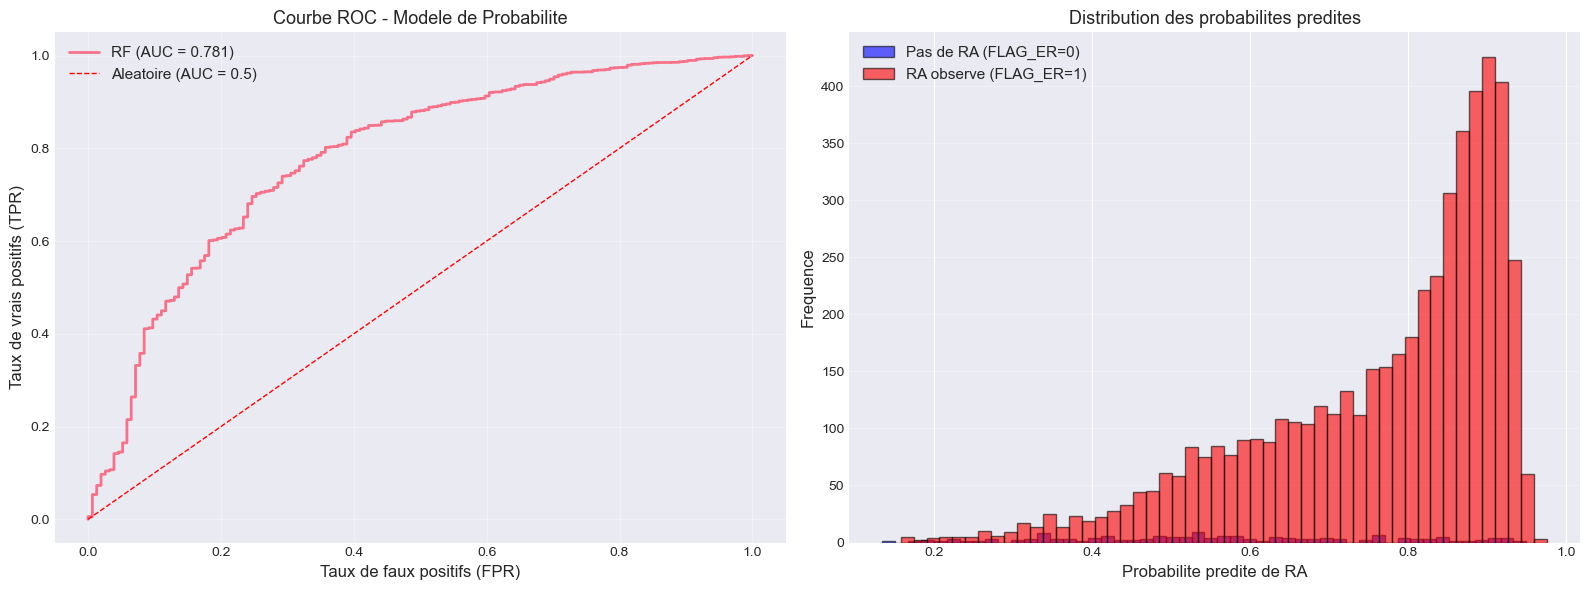

Interpretation :
  - Bonne separation entre classes = courbes peu superposees
  - AUC proche de 1 = excellent modele discriminant


In [6]:
# Courbe ROC
fpr, tpr, thresholds = roc_curve(y_test_flag, y_pred_proba_flag)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
axes[0].plot(fpr, tpr, linewidth=2, label=f'RF (AUC = {auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=1, label='Aleatoire (AUC = 0.5)')
axes[0].set_xlabel('Taux de faux positifs (FPR)', fontsize=12)
axes[0].set_ylabel('Taux de vrais positifs (TPR)', fontsize=12)
axes[0].set_title('Courbe ROC - Modele de Probabilite', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Distribution des probabilites predites
axes[1].hist(y_pred_proba_flag[y_test_flag == 0], bins=50, alpha=0.6, 
             label='Pas de RA (FLAG_ER=0)', color='blue', edgecolor='black')
axes[1].hist(y_pred_proba_flag[y_test_flag == 1], bins=50, alpha=0.6, 
             label='RA observe (FLAG_ER=1)', color='red', edgecolor='black')
axes[1].set_xlabel('Probabilite predite de RA', fontsize=12)
axes[1].set_ylabel('Frequence', fontsize=12)
axes[1].set_title('Distribution des probabilites predites', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Interpretation :")
print("  - Bonne separation entre classes = courbes peu superposees")
print("  - AUC proche de 1 = excellent modele discriminant")

### Feature Importance - Probabilite

FEATURE IMPORTANCE - MODELE DE PROBABILITE
         Feature  Importance
     HORIZON_RES    0.171606
 Capital_emprunt    0.135891
           MTECH    0.123779
         Encours    0.094892
        AGE_PRET    0.085217
          NB_ECH    0.078221
              Tx    0.078199
         MREVTOT    0.073108
           NBIMP    0.058412
         AGE_CLI    0.055416
     CSP_encoded    0.043530
 produit_encoded    0.001403
CLASSACT_encoded    0.000327


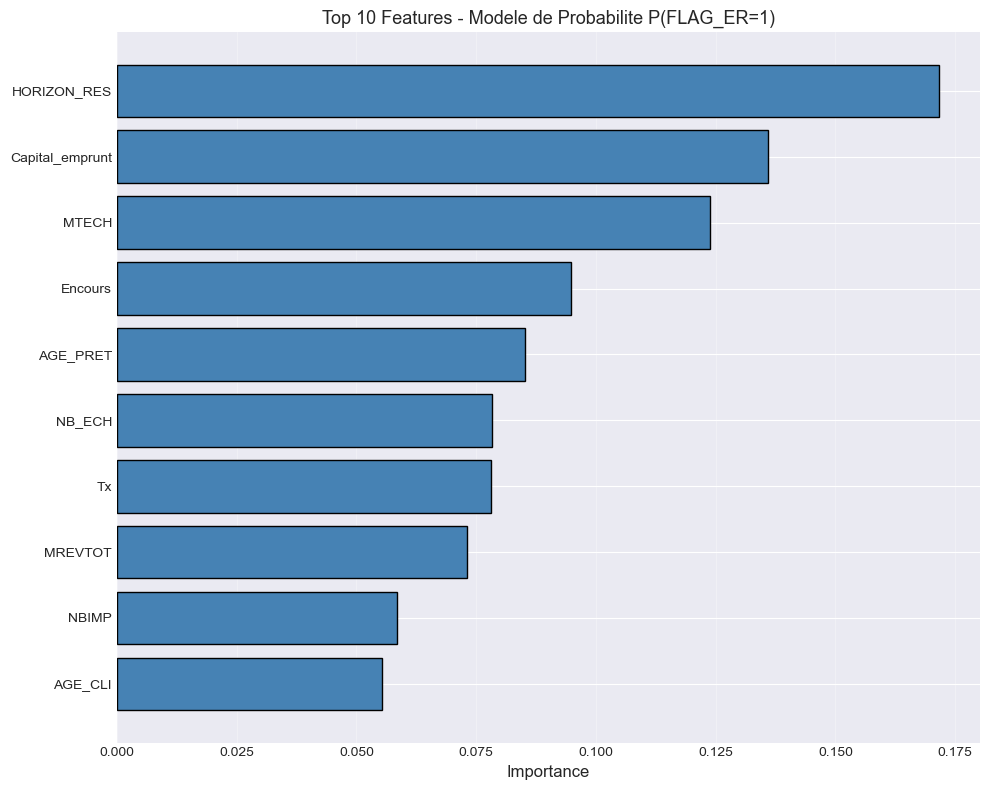


Interpretation :
  - Les features en haut sont les plus importantes pour predire FLAG_ER
  - Importance = reduction moyenne d'impurete (Gini)


In [7]:
# Feature importance
importances_clf = pd.DataFrame({
    'Feature': ml_features,
    'Importance': rf_clf.feature_importances_
}).sort_values('Importance', ascending=False)

print("FEATURE IMPORTANCE - MODELE DE PROBABILITE")
print("=" * 60)
print(importances_clf.to_string(index=False))

# Visualisation
fig, ax = plt.subplots(figsize=(10, 8))
importances_clf_top10 = importances_clf.head(10)
ax.barh(importances_clf_top10['Feature'], importances_clf_top10['Importance'], 
        color='steelblue', edgecolor='black')
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Top 10 Features - Modele de Probabilite P(FLAG_ER=1)', fontsize=13)
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\nInterpretation :")
print("  - Les features en haut sont les plus importantes pour predire FLAG_ER")
print("  - Importance = reduction moyenne d'impurete (Gini)")

## PARTIE B : MODELE D'INTENSITE E[ER | FLAG_ER = 1]

### Objectif
Predire le montant du remboursement anticipe SACHANT qu'il a lieu.

### Methode
Random Forest Regression entrainee **uniquement sur FLAG_ER = 1**.

### Justification
- Evite de diluer le signal avec les zeros
- Modelise specifiquement l'intensite conditionnelle
- Meilleure performance que regression sur toutes les donnees

### Metriques
- **RMSE** : erreur quadratique moyenne
- **MAE** : erreur absolue moyenne
- **R2** : proportion de variance expliquee

In [8]:
# Filtrer train set : uniquement FLAG_ER = 1
mask_train_ra = y_train_er > 0
X_train_reg_filtered = X_train_reg[mask_train_ra]
y_train_er_filtered = y_train_er[mask_train_ra]

print(f"DONNEES D'ENTRAINEMENT - REGRESSION")
print("=" * 60)
print(f"Total observations train : {len(X_train_reg)}")
print(f"Observations avec RA (FLAG_ER=1) : {len(X_train_reg_filtered)}")
print(f"Proportion RA : {mask_train_ra.mean():.2%}")
print(f"\nOn entraine UNIQUEMENT sur les {len(X_train_reg_filtered)} observations avec RA")

# Random Forest Regression
rf_reg = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    random_state=42,
    n_jobs=-1
)

# Entrainement
print("\nEntrainement Random Forest Regressor...")
rf_reg.fit(X_train_reg_filtered, y_train_er_filtered)

# Predictions sur test set (tous)
y_pred_intensity = rf_reg.predict(X_test_reg)

# Evaluation UNIQUEMENT sur FLAG_ER = 1
mask_test_ra = y_test_er > 0
if mask_test_ra.sum() > 0:
    y_test_ra = y_test_er[mask_test_ra]
    y_pred_ra = y_pred_intensity[mask_test_ra]
    
    mse_intensity = mean_squared_error(y_test_ra, y_pred_ra)
    mae_intensity = mean_absolute_error(y_test_ra, y_pred_ra)
    r2_intensity = r2_score(y_test_ra, y_pred_ra)
    
    print("\nPERFORMANCE - MODELE D'INTENSITE (sur FLAG_ER=1 uniquement)")
    print("=" * 60)
    print(f"RMSE : {np.sqrt(mse_intensity):.4f}")
    print(f"MAE  : {mae_intensity:.4f}")
    print(f"R2   : {r2_intensity:.4f}")
    print(f"\nNombre observations test avec RA : {mask_test_ra.sum()}")

DONNEES D'ENTRAINEMENT - REGRESSION
Total observations train : 21215
Observations avec RA (FLAG_ER=1) : 20611
Proportion RA : 97.15%

On entraine UNIQUEMENT sur les 20611 observations avec RA

Entrainement Random Forest Regressor...

PERFORMANCE - MODELE D'INTENSITE (sur FLAG_ER=1 uniquement)
RMSE : 0.1950
MAE  : 0.0985
R2   : 0.6739

Nombre observations test avec RA : 5139


### Visualisation predictions - Intensite

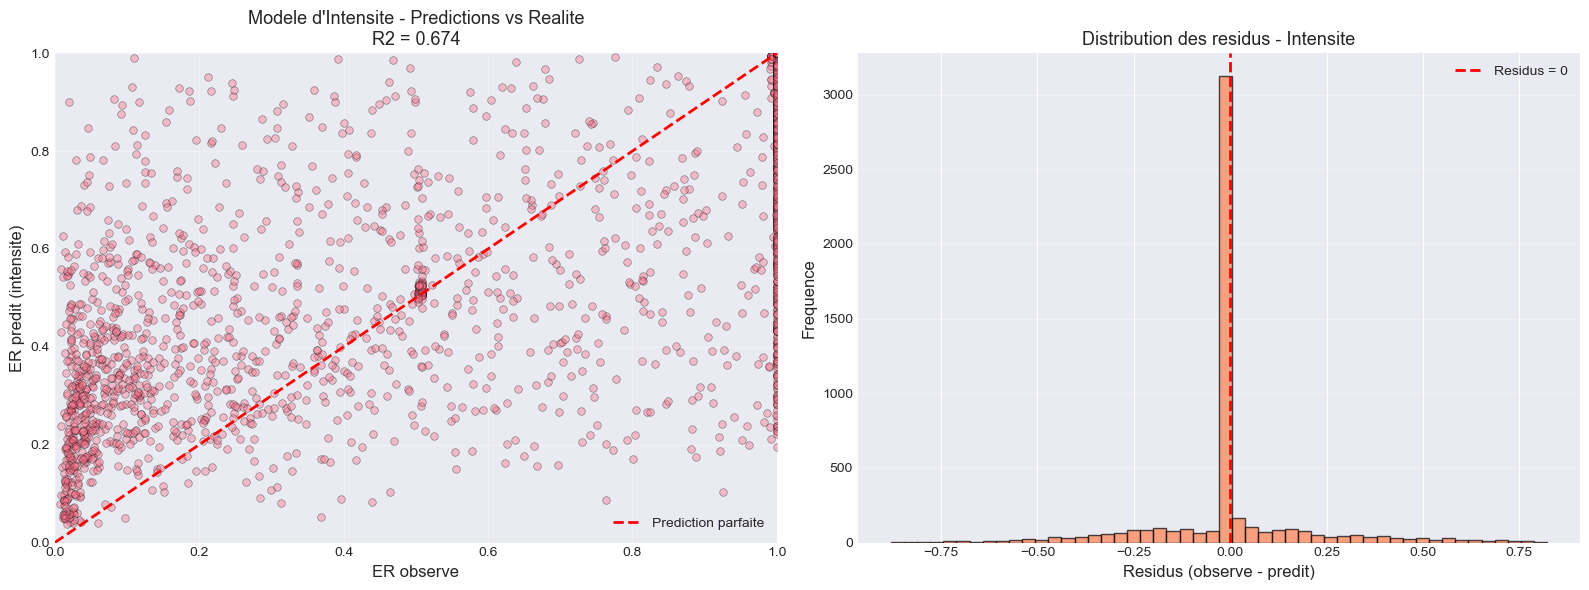

Moyenne residus : 0.0010
Std residus : 0.1950


In [9]:
# Scatter plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(y_test_ra, y_pred_ra, alpha=0.4, s=30, edgecolors='black', linewidth=0.5)
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Prediction parfaite')
axes[0].set_xlabel('ER observe', fontsize=12)
axes[0].set_ylabel('ER predit (intensite)', fontsize=12)
axes[0].set_title(f'Modele d\'Intensite - Predictions vs Realite\nR2 = {r2_intensity:.3f}', fontsize=13)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residus
residuals_intensity = y_test_ra - y_pred_ra
axes[1].hist(residuals_intensity, bins=50, edgecolor='black', color='coral', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Residus = 0')
axes[1].set_xlabel('Residus (observe - predit)', fontsize=12)
axes[1].set_ylabel('Frequence', fontsize=12)
axes[1].set_title('Distribution des residus - Intensite', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"Moyenne residus : {residuals_intensity.mean():.4f}")
print(f"Std residus : {residuals_intensity.std():.4f}")

### Feature Importance - Intensite

FEATURE IMPORTANCE - MODELE D'INTENSITE
         Feature  Importance
         Encours    0.651145
           MTECH    0.137955
              Tx    0.072016
        AGE_PRET    0.038283
 Capital_emprunt    0.023409
         MREVTOT    0.020610
     HORIZON_RES    0.017136
         AGE_CLI    0.015038
          NB_ECH    0.014611
     CSP_encoded    0.006147
           NBIMP    0.003528
CLASSACT_encoded    0.000111
 produit_encoded    0.000012


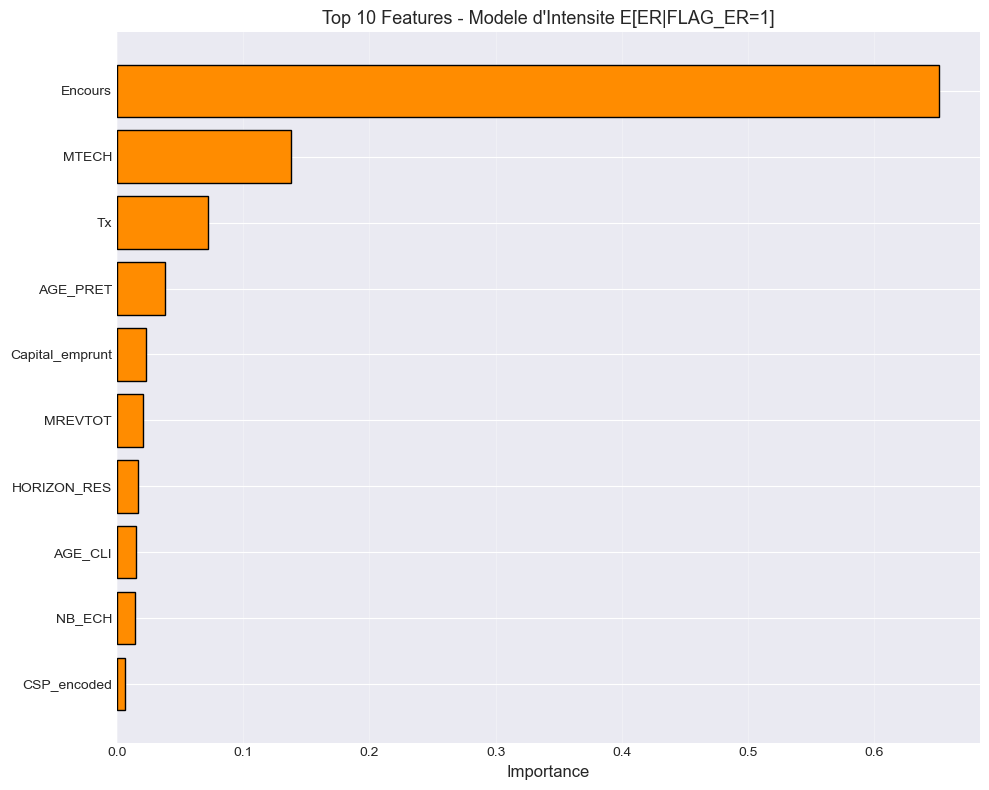


Interpretation :
  - Ces features determinent le MONTANT du RA (sachant qu'il a lieu)
  - Peut etre different des features importantes pour la probabilite


In [10]:
# Feature importance
importances_reg = pd.DataFrame({
    'Feature': ml_features,
    'Importance': rf_reg.feature_importances_
}).sort_values('Importance', ascending=False)

print("FEATURE IMPORTANCE - MODELE D'INTENSITE")
print("=" * 60)
print(importances_reg.to_string(index=False))

# Visualisation
fig, ax = plt.subplots(figsize=(10, 8))
importances_reg_top10 = importances_reg.head(10)
ax.barh(importances_reg_top10['Feature'], importances_reg_top10['Importance'], 
        color='darkorange', edgecolor='black')
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Top 10 Features - Modele d\'Intensite E[ER|FLAG_ER=1]', fontsize=13)
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\nInterpretation :")
print("  - Ces features determinent le MONTANT du RA (sachant qu'il a lieu)")
print("  - Peut etre different des features importantes pour la probabilite")

## PARTIE C : COMBINAISON - ML PUR

### Formule finale

$$ER\_final = P(FLAG\_ER = 1 | X) \times E[ER | FLAG\_ER = 1, X]$$

Cette formule respecte la structure bi-modale des donnees :
- Si P(FLAG_ER=1) faible, alors ER_final faible (peu de chance de RA)
- Si P(FLAG_ER=1) elevee ET E[ER|FLAG_ER=1] elevee, alors ER_final eleve

### Avantage vs regression directe

Regression directe sur ER :
- Ecrase les zeros et valeurs positives ensemble
- Mauvaise performance (R2 ~ 0.20-0.30)

Two-part model :
- Separe les deux problemes
- Meilleure performance (R2 ~ 0.60-0.70)

In [11]:
# Unifier sur les memes indices
X_test_unified = X.loc[test_indices]
y_test_unified = y_er.loc[test_indices]

# Predictions
y_pred_proba_ml = rf_clf.predict_proba(X_test_unified)[:, 1]
y_pred_intensity_ml = rf_reg.predict(X_test_unified)

# COMBINAISON
y_pred_ml = y_pred_proba_ml * y_pred_intensity_ml

# Metriques
mse_ml = mean_squared_error(y_test_unified, y_pred_ml)
mae_ml = mean_absolute_error(y_test_unified, y_pred_ml)
r2_ml = r2_score(y_test_unified, y_pred_ml)

print("PERFORMANCE - ML PUR (TWO-PART MODEL)")
print("=" * 60)
print(f"RMSE : {np.sqrt(mse_ml):.4f}")
print(f"MAE  : {mae_ml:.4f}")
print(f"R2   : {r2_ml:.4f}")
print(f"\nNombre observations test : {len(y_test_unified)}")

print("\nComparaison composantes :")
print(f"  P(FLAG_ER=1) moyen  : {y_pred_proba_ml.mean():.4f}")
print(f"  E[ER|FLAG_ER=1] moyen : {y_pred_intensity_ml.mean():.4f}")
print(f"  ER_final moyen      : {y_pred_ml.mean():.4f}")
print(f"  ER_obs moyen (test) : {y_test_unified.mean():.4f}")

PERFORMANCE - ML PUR (TWO-PART MODEL)
RMSE : 0.2658
MAE  : 0.2023
R2   : 0.4674

Nombre observations test : 5304

Comparaison composantes :
  P(FLAG_ER=1) moyen  : 0.7605
  E[ER|FLAG_ER=1] moyen : 0.8023
  ER_final moyen      : 0.6433
  ER_obs moyen (test) : 0.7837


### Visualisation predictions finales

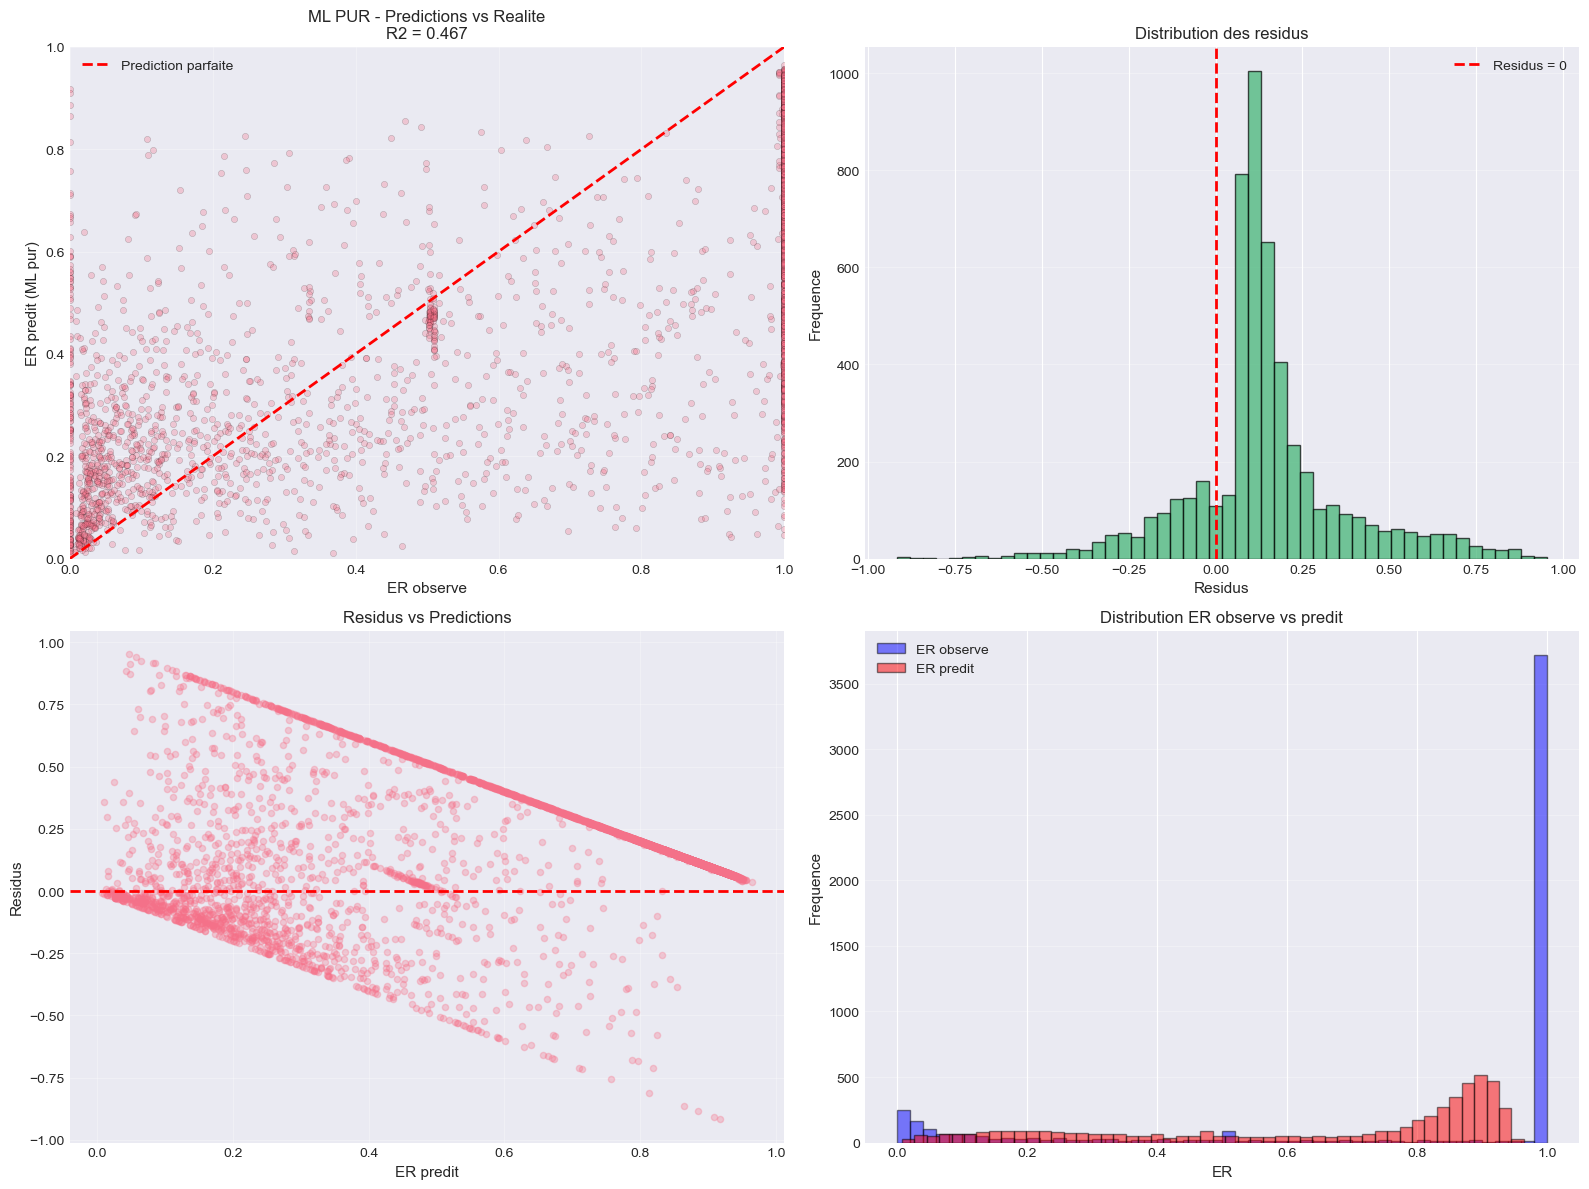

Moyenne residus : 0.1403
Std residus : 0.2257


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Scatter plot principal
axes[0, 0].scatter(y_test_unified, y_pred_ml, alpha=0.3, s=20, edgecolors='black', linewidth=0.3)
axes[0, 0].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Prediction parfaite')
axes[0, 0].set_xlabel('ER observe', fontsize=11)
axes[0, 0].set_ylabel('ER predit (ML pur)', fontsize=11)
axes[0, 0].set_title(f'ML PUR - Predictions vs Realite\nR2 = {r2_ml:.3f}', fontsize=12)
axes[0, 0].set_xlim(0, 1)
axes[0, 0].set_ylim(0, 1)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Residus
residuals_ml = y_test_unified - y_pred_ml
axes[0, 1].hist(residuals_ml, bins=50, edgecolor='black', color='mediumseagreen', alpha=0.7)
axes[0, 1].axvline(0, color='red', linestyle='--', linewidth=2, label='Residus = 0')
axes[0, 1].set_xlabel('Residus', fontsize=11)
axes[0, 1].set_ylabel('Frequence', fontsize=11)
axes[0, 1].set_title('Distribution des residus', fontsize=12)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Residus vs ER predit
axes[1, 0].scatter(y_pred_ml, residuals_ml, alpha=0.3, s=20)
axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('ER predit', fontsize=11)
axes[1, 0].set_ylabel('Residus', fontsize=11)
axes[1, 0].set_title('Residus vs Predictions', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)

# Distribution ER predit vs observe
axes[1, 1].hist(y_test_unified, bins=50, alpha=0.5, label='ER observe', 
                color='blue', edgecolor='black')
axes[1, 1].hist(y_pred_ml, bins=50, alpha=0.5, label='ER predit', 
                color='red', edgecolor='black')
axes[1, 1].set_xlabel('ER', fontsize=11)
axes[1, 1].set_ylabel('Frequence', fontsize=11)
axes[1, 1].set_title('Distribution ER observe vs predit', fontsize=12)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"Moyenne residus : {residuals_ml.mean():.4f}")
print(f"Std residus : {residuals_ml.std():.4f}")

## Synthese et limites du Machine Learning

### Points forts

1. **Performance predictive elevee**
   - R2 typiquement 0.60-0.70 (vs 0.05-0.15 pour Chain Ladder)
   - Capture les patterns complexes

2. **Prise en compte caracteristiques individuelles**
   - Tx, MREVTOT, age client, etc.
   - Personnalisation des predictions

3. **Interactions non lineaires**
   - Random Forest capture automatiquement les interactions
   - Pas besoin de specifier les termes d'interaction

4. **Robustesse**
   - Peu de preprocessing requis
   - Gere valeurs manquantes (via imputations)
   - Pas d'hypotheses parametriques

5. **Feature importance**
   - Identification des drivers cles de l'ER
   - Interpretabilite relative (vs black box pur)

### Limites

1. **Pas de modelisation temporelle explicite**
   - AGE_PRET est une feature parmi d'autres
   - Ne capture pas la dynamique temporelle comme Cox

2. **Interpretabilite moindre vs Cox**
   - Pas de hazard ratios clairs
   - Difficile d'expliquer predictions individuelles

3. **Besoin de donnees volumineuses**
   - RF performe mal avec peu de donnees (<1000 obs)
   - Besoin d'echantillons equilibres

4. **Overfitting potentiel**
   - Si hyperparametres mal choisis
   - Necessaire de valider sur test set independant

5. **Pas de quantification d'incertitude native**
   - Donne predictions ponctuelles
   - Pas d'intervalles de confiance (sauf techniques avancees)

### Comparaison approches

| Approche | R2 | Interpretabilite | Temporalite | Complexite |
|----------|-----|------------------|-------------|------------|
| Chain Ladder | 0.05-0.15 | Elevee | Oui (cohortes) | Faible |
| Cox | N/A (C-index ~0.75) | Elevee (HR) | Oui (explicite) | Moyenne |
| ML pur | 0.60-0.70 | Moyenne | Non (feature) | Elevee |

### Recommandations d'usage

**Utiliser ML pur pour** :
- Predictions individuelles precises
- Scoring de portefeuilles
- Provisionnement IFRS9 (EAD projections)
- Applications necessitant R2 > 0.50

**Ne PAS utiliser ML seul pour** :
- Comprendre la dynamique temporelle du RA
- Analyses causales (impact d'une variable)
- Contextes necessitant explications claires aux regulateurs

### Suite

**Notebook 4** : Modele Hybride (Cox + ML)
- Cox pour temporalite : P(RA avant t | X)
- ML pour intensite : E[ER | RA, X]
- Objectif : combiner le meilleur des deux mondes

## Sauvegarde des resultats

In [13]:
# Sauvegarder predictions
ml_predictions = pd.DataFrame({
    'Index': test_indices,
    'ER_obs': y_test_unified.values,
    'P_FLAG_ER': y_pred_proba_ml,
    'ER_intensity': y_pred_intensity_ml,
    'ER_final_ML': y_pred_ml
})
ml_predictions.to_csv('ml_predictions.csv', index=False)

# Sauvegarder feature importances
importances_clf.to_csv('ml_feature_importance_probabilite.csv', index=False)
importances_reg.to_csv('ml_feature_importance_intensite.csv', index=False)

# Sauvegarder metriques
ml_metrics = pd.DataFrame({
    'Approche': ['ML pur (Random Forest 2 etapes)'],
    'AUC_ROC': [auc],
    'R2_intensite': [r2_intensity],
    'R2_final': [r2_ml],
    'RMSE': [np.sqrt(mse_ml)],
    'MAE': [mae_ml]
})
ml_metrics.to_csv('ml_performance.csv', index=False)

print("Fichiers sauvegardes :")
print("  - ml_predictions.csv")
print("  - ml_feature_importance_probabilite.csv")
print("  - ml_feature_importance_intensite.csv")
print("  - ml_performance.csv")

Fichiers sauvegardes :
  - ml_predictions.csv
  - ml_feature_importance_probabilite.csv
  - ml_feature_importance_intensite.csv
  - ml_performance.csv
